# Best Submission — Score 0.8877

Complete end-to-end: Preprocess → Train → Fix SWA → Ensemble → Submit

**Input:** raw competition dataset (for preprocessing)

**Pipeline:**
1. Preprocessing: build `norm_stats.npy`, episode masks, monthly data, `test_data.npy` in `/kaggle/working`
2. Phase 1: balanced loss (0.25 each), lr=2e-3, 30 epochs, patience=8
3. Phase 2: episode-heavy loss, lr=4e-4, 15 epochs, patience=6
4. Build SWA from P1+P2 weight average with fixed BN update
5. Ensemble: 0.5 * P2 + 0.5 * SWA → preds.npy

In [1]:
# === Preprocessing (merged from PreProcess.ipynb) ===
import os
import gc
import time
import numpy as np
from statsmodels.tsa.seasonal import STL
from multiprocessing import Pool, cpu_count

# ─── Paths ───
DATA_ROOT = '/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2'
RAW_DIR   = os.path.join(DATA_ROOT, 'raw')
TEST_DIR  = os.path.join(DATA_ROOT, 'test_in')
OUT_DIR   = '/kaggle/working'

# ─── Constants ───
MONTHS = ['APRIL_16', 'JULY_16', 'OCT_16', 'DEC_16']
BASE_FEATURES = ['cpm25', 'q2', 't2', 'u10', 'v10', 'swdown', 'pblh', 'psfc', 'rain',
                 'PM25', 'NH3', 'SO2', 'NOx', 'NMVOC_e', 'NMVOC_finn', 'bio']
# Final features: 16 base + 2 time encoding + 2 derived = 20
ALL_FEATURES = BASE_FEATURES + ['hour_sin', 'hour_cos', 'wind_speed', 'cpm25_diff']
N_FEATURES = len(ALL_FEATURES)  # 20

SEED = 42
np.random.seed(SEED)
print(f'Base features: {len(BASE_FEATURES)}, Total features: {N_FEATURES}')

# ─── 1) Compute Mean/Std Normalization Statistics ───
NORM_PATH = os.path.join(OUT_DIR, 'norm_stats.npy')

if os.path.exists(NORM_PATH):
    print('norm_stats.npy exists — loading cached.')
    norm_stats = np.load(NORM_PATH, allow_pickle=True).item()
else:
    print('Computing mean/std normalization stats...')
    norm_stats = {}

    # Base features: compute from raw data
    for feat in BASE_FEATURES:
        total_sum = 0.0
        total_sq = 0.0
        total_count = 0
        for month in MONTHS:
            arr = np.load(os.path.join(RAW_DIR, month, f'{feat}.npy')).astype(np.float64)
            total_sum += arr.sum()
            total_sq += (arr * arr).sum()
            total_count += arr.size
            del arr
        mean = total_sum / max(total_count, 1)
        var = max((total_sq / max(total_count, 1)) - mean * mean, 1e-8)
        std = float(np.sqrt(var))
        norm_stats[feat] = {'mean': float(mean), 'std': std}
        print(f'  {feat}: mean={mean:.6f}, std={std:.6f}')
        gc.collect()

    # Derived features: compute stats after creating them (done in step 3)
    # For now, placeholders — will be updated
    norm_stats['hour_sin'] = {'mean': 0.0, 'std': 1.0}  # sin is already ~N(0,1)
    norm_stats['hour_cos'] = {'mean': 0.0, 'std': 1.0}
    # wind_speed and cpm25_diff stats computed below

    # Compute wind_speed stats
    ws_sum, ws_sq, ws_count = 0.0, 0.0, 0
    for month in MONTHS:
        u = np.load(os.path.join(RAW_DIR, month, 'u10.npy')).astype(np.float64)
        v = np.load(os.path.join(RAW_DIR, month, 'v10.npy')).astype(np.float64)
        ws = np.sqrt(u**2 + v**2)
        ws_sum += ws.sum()
        ws_sq += (ws * ws).sum()
        ws_count += ws.size
        del u, v, ws
        gc.collect()
    ws_mean = ws_sum / max(ws_count, 1)
    ws_std = float(np.sqrt(max((ws_sq / max(ws_count, 1)) - ws_mean**2, 1e-8)))
    norm_stats['wind_speed'] = {'mean': float(ws_mean), 'std': ws_std}
    print(f'  wind_speed: mean={ws_mean:.6f}, std={ws_std:.6f}')

    # Compute cpm25_diff stats
    diff_sum, diff_sq, diff_count = 0.0, 0.0, 0
    for month in MONTHS:
        cpm = np.load(os.path.join(RAW_DIR, month, 'cpm25.npy')).astype(np.float64)
        diff = np.diff(cpm, axis=0)  # (T-1, H, W)
        diff_sum += diff.sum()
        diff_sq += (diff * diff).sum()
        diff_count += diff.size
        del cpm, diff
        gc.collect()
    diff_mean = diff_sum / max(diff_count, 1)
    diff_std = float(np.sqrt(max((diff_sq / max(diff_count, 1)) - diff_mean**2, 1e-8)))
    norm_stats['cpm25_diff'] = {'mean': float(diff_mean), 'std': diff_std}
    print(f'  cpm25_diff: mean={diff_mean:.6f}, std={diff_std:.6f}')

    np.save(NORM_PATH, norm_stats)
    print('Saved norm_stats.npy')

# Extract cpm25 stats for loss denormalization
cpm_mean = norm_stats['cpm25']['mean']
cpm_std = norm_stats['cpm25']['std']
print(f'\ncpm25: mean={cpm_mean:.4f}, std={cpm_std:.4f}')

# ─── 2) Compute Episode Masks (robust=True, matching official evaluation) ───
def _stl_worker(args):
    data_chunk, col_range = args
    T, n_cols = data_chunk.shape
    mask_chunk = np.zeros((T, n_cols), dtype=np.uint8)
    for i in range(n_cols):
        ts = data_chunk[:, i]
        stl = STL(ts, period=24, robust=True)  # robust=True matches official eval
        res = stl.fit()
        remainder = res.resid
        std_val = np.std(remainder) + 1e-8
        mask_chunk[:, i] = ((remainder > 3 * std_val) & (ts > 1)).astype(np.uint8)
    return col_range, mask_chunk

for month in MONTHS:
    mask_path = os.path.join(OUT_DIR, f'{month}_episode_mask.npy')
    if os.path.exists(mask_path):
        mask = np.load(mask_path, mmap_mode='r')
        print(f'{month} mask: exists — ratio={mask.mean():.6f}')
        continue

    t0 = time.time()
    cpm = np.load(os.path.join(RAW_DIR, month, 'cpm25.npy'))
    T, H, W = cpm.shape
    data_2d = cpm.reshape(T, -1)
    n_grid = data_2d.shape[1]

    n_workers = min(cpu_count(), 4)
    chunk_size = max(1, n_grid // (n_workers * 4))
    chunks = []
    for start in range(0, n_grid, chunk_size):
        end = min(start + chunk_size, n_grid)
        chunks.append((data_2d[:, start:end].copy(), (start, end)))

    mask_2d = np.zeros_like(data_2d, dtype=np.uint8)
    with Pool(n_workers) as pool:
        for (start, end), mask_chunk in pool.imap_unordered(_stl_worker, chunks):
            mask_2d[:, start:end] = mask_chunk

    mask = mask_2d.reshape(T, H, W)
    np.save(mask_path, mask)
    print(f'{month} mask: ratio={mask.mean():.6f} ({time.time()-t0:.0f}s)')
    del cpm, data_2d, mask_2d, mask
    gc.collect()

# ─── 3) Normalize, Add Derived Features, Save Monthly Data ───
def normalize(arr, feat_name):
    s = norm_stats[feat_name]
    return (arr - s['mean']) / s['std']

for month in MONTHS:
    out_path = os.path.join(OUT_DIR, f'{month}_data.npy')
    if os.path.exists(out_path):
        arr = np.load(out_path, mmap_mode='r')
        print(f'{month}: exists — shape={arr.shape}')
        continue

    t0 = time.time()
    channels = []

    # ── 16 base features ──
    raw_cache = {}
    for feat in BASE_FEATURES:
        arr = np.load(os.path.join(RAW_DIR, month, f'{feat}.npy')).astype(np.float32)
        if feat in ('u10', 'v10', 'cpm25'):
            raw_cache[feat] = arr.copy()
        channels.append(normalize(arr, feat))
        del arr

    # ── Time-of-day encoding ──
    time_arr = np.load(os.path.join(RAW_DIR, month, 'time.npy'))
    # time.npy contains strings like '2016-04-01 00:00:00' (dtype <U19)
    # Parse hour from the string
    if np.issubdtype(time_arr.dtype, np.str_) or np.issubdtype(time_arr.dtype, np.bytes_):
        # Extract hour from datetime strings
        hours = np.array([int(str(t).split('T')[1].split(':')[0]) for t in time_arr], dtype=np.float32)
    elif np.issubdtype(time_arr.dtype, np.datetime64):
        hours = (time_arr - time_arr.astype('datetime64[D]')).astype('timedelta64[h]').astype(np.float32)
    else:
        hours = (time_arr % 24).astype(np.float32)

    T = channels[0].shape[0]
    H, W = channels[0].shape[1], channels[0].shape[2]

    hour_sin = np.sin(2 * np.pi * hours / 24).reshape(T, 1, 1) * np.ones((1, H, W), dtype=np.float32)
    hour_cos = np.cos(2 * np.pi * hours / 24).reshape(T, 1, 1) * np.ones((1, H, W), dtype=np.float32)
    channels.append(hour_sin)
    channels.append(hour_cos)

    # ── Wind speed ──
    ws = np.sqrt(raw_cache['u10']**2 + raw_cache['v10']**2)
    channels.append(normalize(ws, 'wind_speed'))
    del ws

    # ── PM2.5 temporal difference ──
    cpm_diff = np.zeros_like(raw_cache['cpm25'])
    cpm_diff[1:] = raw_cache['cpm25'][1:] - raw_cache['cpm25'][:-1]
    channels.append(normalize(cpm_diff, 'cpm25_diff'))
    del cpm_diff, raw_cache

    # ── Stack and save ──
    month_data = np.stack(channels, axis=-1).astype(np.float16)  # (T, 140, 124, 20)
    del channels
    gc.collect()

    np.save(out_path, month_data)
    print(f'{month}: saved {month_data.shape} ({time.time()-t0:.0f}s, {os.path.getsize(out_path)/1e6:.0f} MB)')
    del month_data
    gc.collect()

# ─── 4) Normalize and Save Test Inputs ───
TEST_DATA_PATH = os.path.join(OUT_DIR, 'test_data.npy')

if os.path.exists(TEST_DATA_PATH):
    arr = np.load(TEST_DATA_PATH, mmap_mode='r')
    print(f'test_data.npy exists — shape={arr.shape}')
else:
    print('Normalizing test inputs...')
    # Load base features
    test_raw = {}
    for feat in BASE_FEATURES:
        test_raw[feat] = np.load(os.path.join(TEST_DIR, f'{feat}.npy')).astype(np.float32)

    N_test, T_test = test_raw['cpm25'].shape[0], test_raw['cpm25'].shape[1]
    H, W = test_raw['cpm25'].shape[2], test_raw['cpm25'].shape[3]
    print(f'  Test: {N_test} samples, {T_test} timesteps, ({H},{W}) grid')

    channels = []
    # Base features
    for feat in BASE_FEATURES:
        channels.append(normalize(test_raw[feat], feat))

    # Time-of-day: we don't have test time.npy, use zeros (model should handle)
    hour_sin = np.zeros((N_test, T_test, H, W), dtype=np.float32)
    hour_cos = np.zeros((N_test, T_test, H, W), dtype=np.float32)
    channels.append(hour_sin)
    channels.append(hour_cos)

    # Wind speed
    ws = np.sqrt(test_raw['u10']**2 + test_raw['v10']**2)
    channels.append(normalize(ws, 'wind_speed'))
    del ws

    # PM2.5 temporal difference
    cpm_diff = np.zeros_like(test_raw['cpm25'])
    cpm_diff[:, 1:] = test_raw['cpm25'][:, 1:] - test_raw['cpm25'][:, :-1]
    channels.append(normalize(cpm_diff, 'cpm25_diff'))
    del cpm_diff, test_raw
    gc.collect()

    test_data = np.stack(channels, axis=-1).astype(np.float16)  # (N, 10, 140, 124, 20)
    del channels
    gc.collect()

    np.save(TEST_DATA_PATH, test_data)
    print(f'  Saved test_data.npy: {test_data.shape}')
    del test_data
    gc.collect()

# ─── Cleanup and verify ───
for f in os.listdir(OUT_DIR):
    if f.startswith('_temp_') or f == 'episode_masks.npy':
        os.remove(os.path.join(OUT_DIR, f))
        print(f'Deleted: {f}')

print('\nOutput files:')
total_mb = 0
for f in sorted(os.listdir(OUT_DIR)):
    if f.startswith('.'):
        continue
    path = os.path.join(OUT_DIR, f)
    size_mb = os.path.getsize(path) / 1e6
    total_mb += size_mb
    print(f'  {f}: {size_mb:.1f} MB')
    if f.endswith('.npy'):
        try:
            arr = np.load(path, mmap_mode='r')
            print(f'    shape={arr.shape}, dtype={arr.dtype}')
        except ValueError:
            arr = np.load(path, allow_pickle=True)
            print(f'    (dict with {len(arr.item())} keys)')
print(f'\nTotal: {total_mb/1e3:.2f} GB')

Base features: 16, Total features: 20
Computing mean/std normalization stats...
  cpm25: mean=33.607726, std=52.277586
  q2: mean=0.011485, std=0.007026
  t2: mean=291.594041, std=14.066833
  u10: mean=1.547574, std=3.547141
  v10: mean=0.137301, std=2.995834
  swdown: mean=221.780578, std=309.406719
  pblh: mean=764.290133, std=636.343598
  psfc: mean=87987.006880, std=17645.765547
  rain: mean=0.094795, std=1.070709
  PM25: mean=0.000000, std=0.000100
  NH3: mean=0.000000, std=0.000100
  SO2: mean=0.000000, std=0.000100
  NOx: mean=0.000000, std=0.000100
  NMVOC_e: mean=0.000000, std=0.000100
  NMVOC_finn: mean=0.000000, std=0.000100
  bio: mean=0.000000, std=0.000100
  wind_speed: mean=4.178932, std=2.550999
  cpm25_diff: mean=0.015153, std=6.653998
Saved norm_stats.npy

cpm25: mean=33.6077, std=52.2776
APRIL_16 mask: ratio=0.020785 (657s)
JULY_16 mask: ratio=0.019730 (684s)
OCT_16 mask: ratio=0.017039 (684s)
DEC_16 mask: ratio=0.021735 (670s)
APRIL_16: saved (715, 140, 124, 20) (12

In [2]:
import os, gc, time, json, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim.swa_utils as swa_utils
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Preprocessing outputs live in /kaggle/working from the merged section above
OUT_DIR = '/kaggle/working'
PREPROC_DIR = OUT_DIR
os.makedirs(OUT_DIR, exist_ok=True)

MONTHS = ['APRIL_16', 'JULY_16', 'OCT_16', 'DEC_16']
N_FEATURES = 20
T_IN, T_OUT = 10, 16
WINDOW = T_IN + T_OUT
BASE_CH = 48
DROPOUT = 0.05
BATCH_SIZE = 4
SEED = 42
VAL_RATIO = 0.15
MIN_GAP = T_OUT
STRIDE = 1

def seed_everything(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

norm_stats = np.load(os.path.join(PREPROC_DIR, 'norm_stats.npy'), allow_pickle=True).item()
CPM_MEAN = norm_stats['cpm25']['mean']
CPM_STD = norm_stats['cpm25']['std']
print(f'Device: {DEVICE}, cpm25: mean={CPM_MEAN:.4f}, std={CPM_STD:.4f}')

Device: cuda, cpm25: mean=33.6077, std=52.2776


In [3]:
# ═══ Dataset + Chronological Split ═══

class PM25Dataset(Dataset):
    def __init__(self, md, mm, idx):
        self.d, self.m, self.idx = md, mm, idx
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        mi, t = self.idx[i]
        w = self.d[mi][t:t+WINDOW].astype(np.float32)
        mk = self.m[mi][t+T_IN:t+WINDOW].astype(np.float32)
        return (torch.from_numpy(w[:T_IN].copy()),
                torch.from_numpy(w[T_IN:,:,:,0].copy()),
                torch.from_numpy(mk.copy()))

# For SWA BN update: returns only x
class XOnlyDataset(Dataset):
    def __init__(self, md, idx):
        self.d, self.idx = md, idx
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        mi, t = self.idx[i]
        x = self.d[mi][t:t+T_IN].astype(np.float32)
        return torch.from_numpy(x.copy())

month_data = [np.load(os.path.join(PREPROC_DIR, f'{mo}_data.npy'), mmap_mode='r') for mo in MONTHS]
month_masks = [np.load(os.path.join(PREPROC_DIR, f'{mo}_episode_mask.npy'), mmap_mode='r') for mo in MONTHS]
for i, mo in enumerate(MONTHS):
    print(f'{mo}: data={month_data[i].shape}, mask={month_masks[i].shape}')

train_idx, val_idx = [], []
for mi, mo in enumerate(MONTHS):
    T_mo = month_data[mi].shape[0]
    n_win = T_mo - WINDOW + 1
    split = int((1.0 - VAL_RATIO) * n_win)
    train_end = max(split - MIN_GAP, 1)
    for t in range(0, train_end, STRIDE): train_idx.append((mi, t))
    for t in range(split, n_win):         val_idx.append((mi, t))
    print(f'  {mo}: {train_end} train, {n_win - split} val')

print(f'\nTotal: Train={len(train_idx)}, Val={len(val_idx)}')

train_ds = PM25Dataset(month_data, month_masks, train_idx)
val_ds = PM25Dataset(month_data, month_masks, val_idx)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, persistent_workers=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=True)
print(f'Batches: Train={len(train_loader)}, Val={len(val_loader)}')

APRIL_16: data=(715, 140, 124, 20), mask=(715, 140, 124)
JULY_16: data=(739, 140, 124, 20), mask=(739, 140, 124)
OCT_16: data=(739, 140, 124, 20), mask=(739, 140, 124)
DEC_16: data=(739, 140, 124, 20), mask=(739, 140, 124)
  APRIL_16: 570 train, 104 val
  JULY_16: 590 train, 108 val
  OCT_16: 590 train, 108 val
  DEC_16: 590 train, 108 val

Total: Train=2340, Val=428
Batches: Train=585, Val=107


In [4]:
# ═══ Model ═══

def make_norm(ch):
    for g in [16, 8, 4, 2, 1]:
        if ch % g == 0: return nn.GroupNorm(g, ch)
    return nn.GroupNorm(1, ch)

class SEBlock(nn.Module):
    def __init__(self, ch, r=4):
        super().__init__()
        self.fc1 = nn.Linear(ch, ch // r)
        self.fc2 = nn.Linear(ch // r, ch)
    def forward(self, x):
        w = torch.sigmoid(self.fc2(F.relu(self.fc1(x.mean(dim=(2, 3))))))
        return x * w.unsqueeze(-1).unsqueeze(-1)

class ResBlock(nn.Module):
    def __init__(self, inc, outc, drop=0.0):
        super().__init__()
        self.c1 = nn.Conv2d(inc, outc, 3, padding=1, bias=False)
        self.n1 = make_norm(outc)
        self.c2 = nn.Conv2d(outc, outc, 3, padding=1, bias=False)
        self.n2 = make_norm(outc)
        self.act = nn.SiLU(inplace=True)
        self.drop = nn.Dropout2d(drop) if drop > 0 else nn.Identity()
        self.skip = nn.Conv2d(inc, outc, 1, bias=False) if inc != outc else nn.Identity()
    def forward(self, x):
        r = self.skip(x)
        x = self.act(self.n1(self.c1(x)))
        x = self.drop(x)
        x = self.n2(self.c2(x))
        return self.act(x + r)

class Down(nn.Module):
    def __init__(self, inc, outc, drop=0.0):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.block = ResBlock(inc, outc, drop)
    def forward(self, x): return self.block(self.pool(x))

class Up(nn.Module):
    def __init__(self, inc, skipc, outc, drop=0.0):
        super().__init__()
        self.up = nn.ConvTranspose2d(inc, outc, 2, stride=2)
        self.block = ResBlock(outc + skipc, outc, drop)
    def forward(self, x, skip):
        x = self.up(x)
        dy, dx = skip.size(2) - x.size(2), skip.size(3) - x.size(3)
        if dy or dx: x = F.pad(x, [dx//2, dx-dx//2, dy//2, dy-dy//2])
        return self.block(torch.cat([x, skip], 1))

class EnhancedUNet(nn.Module):
    def __init__(self):
        super().__init__()
        inc = T_IN * N_FEATURES + 2
        b, d = BASE_CH, DROPOUT
        self.enc1 = ResBlock(inc, b, d)
        self.enc2 = Down(b, b*2, d)
        self.enc3 = Down(b*2, b*4, d)
        self.enc4 = Down(b*4, b*8, d)
        self.bottleneck = ResBlock(b*8, b*8, d)
        self.se = SEBlock(b*8)
        self.up3 = Up(b*8, b*4, b*4, d)
        self.up2 = Up(b*4, b*2, b*2, d)
        self.up1 = Up(b*2, b, b, d)
        self.head = nn.Conv2d(b, T_OUT, 1)
    @staticmethod
    def get_grid(B, H, W, dev):
        yy = torch.linspace(-1, 1, H, device=dev).view(1,1,H,1).expand(B,1,H,W)
        xx = torch.linspace(-1, 1, W, device=dev).view(1,1,1,W).expand(B,1,H,W)
        return torch.cat([yy, xx], 1)
    def forward(self, x):
        B, T, H, W, C = x.shape
        x = x.permute(0,1,4,2,3).reshape(B, T*C, H, W)
        x = torch.cat([x, self.get_grid(B, H, W, x.device)], 1)
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        b = self.se(self.bottleneck(s4))
        d3 = self.up3(b, s3)
        d2 = self.up2(d3, s2)
        d1 = self.up1(d2, s1)
        return self.head(d1)

model = EnhancedUNet().to(DEVICE)
print(f'Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Params: 7,352,704


In [5]:
# ═══ Loss ═══

class CompetitionMetricLoss(nn.Module):
    def __init__(self, cpm_mean, cpm_std, w_l1, w_gs, w_es, w_ec):
        super().__init__()
        self.cpm_mean, self.cpm_std = cpm_mean, cpm_std
        self.w_l1, self.w_gs, self.w_es, self.w_ec = w_l1, w_gs, w_es, w_ec
    def forward(self, pred_norm, target_norm, episode_mask):
        l1 = F.l1_loss(pred_norm, target_norm)
        pred = pred_norm * self.cpm_std + self.cpm_mean
        tgt = target_norm * self.cpm_std + self.cpm_mean
        sm = torch.abs(pred - tgt) / (0.5 * (torch.abs(pred) + torch.abs(tgt)) + 1e-3)
        gs = sm.mean()
        ms = episode_mask.sum() + 1e-6
        es = (sm * episode_mask).sum() / ms
        B, T, H, W = pred.shape
        pf, tf, mf = pred.reshape(B,T,-1), tgt.reshape(B,T,-1), episode_mask.reshape(B,T,-1)
        ecl = []
        for ti in range(T):
            pt, yt, mt = pf[:,ti,:], tf[:,ti,:], mf[:,ti,:]
            ws = mt.sum(1, keepdim=True)
            v = (ws.squeeze(1) > 50).float()
            pm = (pt*mt).sum(1,keepdim=True)/(ws+1e-6)
            ym = (yt*mt).sum(1,keepdim=True)/(ws+1e-6)
            pc, yc = (pt-pm)*mt, (yt-ym)*mt
            cm_ = (pc*yc).sum(1)/(torch.sqrt(pc.pow(2).sum(1)*yc.pow(2).sum(1)+1e-8)+1e-8)
            pa, ya = pt-pt.mean(1,keepdim=True), yt-yt.mean(1,keepdim=True)
            cg = (pa*ya).sum(1)/(torch.sqrt(pa.pow(2).sum(1)*ya.pow(2).sum(1)+1e-8)+1e-8)
            ecl.append(1.0-(v*cm_+(1-v)*cg).mean())
        ec = torch.stack(ecl).mean()
        total = self.w_l1*l1 + self.w_gs*gs + self.w_es*es + self.w_ec*ec
        return total, {'l1':l1.item(),'gs':gs.item(),'es':es.item(),'ec':ec.item()}

In [6]:
# ═══ Training Function ═══

def train_phase(model, train_ld, val_ld, criterion, device,
                lr, epochs, patience, phase_name, ckpt_path):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr*0.05)
    scaler = torch.amp.GradScaler('cuda')
    best_val, pat_ctr = float('inf'), 0
    history = []

    print(f'\n{"="*90}')
    print(f'{phase_name}: lr={lr}, epochs={epochs}, patience={patience}')
    print(f'Weights: L1={criterion.w_l1}, GS={criterion.w_gs}, ES={criterion.w_es}, EC={criterion.w_ec}')
    print(f'{"="*90}')

    for ep in range(1, epochs+1):
        t0 = time.time()
        model.train()
        tl_s, tl_c = 0.0, 0
        for x,y,m in train_ld:
            x,y,m = x.to(device),y.to(device),m.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                pred = model(x)
                loss, _ = criterion(pred, y, m)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            tl_s += loss.item()*x.size(0); tl_c += x.size(0)
        scheduler.step()

        model.eval()
        vl_s, vl_c = 0.0, 0
        vp = {'l1':0,'gs':0,'es':0,'ec':0}
        with torch.no_grad():
            for x,y,m in val_ld:
                x,y,m = x.to(device),y.to(device),m.to(device)
                with torch.amp.autocast('cuda'):
                    pred = model(x)
                    loss, parts = criterion(pred, y, m)
                vl_s += loss.item()*x.size(0); vl_c += x.size(0)
                for k in vp: vp[k] += parts[k]*x.size(0)
        vl = vl_s/vl_c
        for k in vp: vp[k] /= vl_c
        score = ((1-vp['gs']/2)+((1-vp['ec'])+1)/2+(1-vp['es']/2))/3
        elapsed = time.time()-t0

        imp = vl < best_val
        if imp:
            best_val = vl; pat_ctr = 0
            torch.save({'model_state_dict':model.state_dict(),
                        'val_loss':vl,'epoch':ep,'score':score}, ckpt_path)
        else: pat_ctr += 1

        print(f'E{ep:3d}/{epochs} T:{tl_s/tl_c:.5f} V:{vl:.5f}{" *" if imp else ""} | '
              f'L1:{vp["l1"]:.4f} GS:{vp["gs"]:.4f} ES:{vp["es"]:.4f} EC:{vp["ec"]:.4f} | '
              f'Score~{score:.4f} | {elapsed:.0f}s P:{pat_ctr}/{patience}')
        history.append({'epoch':ep,'train_loss':tl_s/tl_c,'val_loss':vl,**vp,'score':score})
        if pat_ctr >= patience: print('Early stopping.'); break

    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'{phase_name} done. Best val: {best_val:.6f}')
    return best_val, history

In [7]:
# ═══ Phase 1: Balanced ═══
all_history = []

crit_p1 = CompetitionMetricLoss(CPM_MEAN, CPM_STD,
    w_l1=0.25, w_gs=0.25, w_es=0.25, w_ec=0.25).to(DEVICE)
best_p1, h1 = train_phase(
    model, train_loader, val_loader, crit_p1, DEVICE,
    lr=2e-3, epochs=30, patience=8,
    phase_name='Phase1-Balanced',
    ckpt_path=os.path.join(OUT_DIR, 'best_p1.pt'))
all_history.extend(h1)

# ═══ Phase 2: Episode Focus ═══
crit_p2 = CompetitionMetricLoss(CPM_MEAN, CPM_STD,
    w_l1=0.15, w_gs=0.20, w_es=0.35, w_ec=0.30).to(DEVICE)
best_p2, h2 = train_phase(
    model, train_loader, val_loader, crit_p2, DEVICE,
    lr=4e-4, epochs=15, patience=6,
    phase_name='Phase2-Episode',
    ckpt_path=os.path.join(OUT_DIR, 'best_p2.pt'))
all_history.extend(h2)

with open(os.path.join(OUT_DIR, 'train_log.json'), 'w') as f:
    json.dump(all_history, f, indent=2)
print(f'\nTraining done. P1: {best_p1:.6f}, P2: {best_p2:.6f}')


Phase1-Balanced: lr=0.002, epochs=30, patience=8
Weights: L1=0.25, GS=0.25, ES=0.25, EC=0.25
E  1/30 T:0.24849 V:0.21462 * | L1:0.1688 GS:0.3359 ES:0.2713 EC:0.0825 | Score~0.8850 | 123s P:0/8
E  2/30 T:0.19521 V:0.19561 * | L1:0.1613 GS:0.3153 ES:0.2243 EC:0.0816 | Score~0.8965 | 114s P:0/8
E  3/30 T:0.17727 V:0.19190 * | L1:0.1649 GS:0.2921 ES:0.2341 EC:0.0765 | Score~0.8996 | 114s P:0/8
E  4/30 T:0.16384 V:0.17750 * | L1:0.1374 GS:0.2666 ES:0.2313 EC:0.0747 | Score~0.9046 | 114s P:0/8
E  5/30 T:0.15241 V:0.17943 | L1:0.1343 GS:0.2587 ES:0.2508 EC:0.0739 | Score~0.9028 | 114s P:1/8
E  6/30 T:0.14125 V:0.17862 | L1:0.1310 GS:0.2583 ES:0.2478 EC:0.0774 | Score~0.9028 | 114s P:2/8
E  7/30 T:0.13282 V:0.17111 * | L1:0.1264 GS:0.2433 ES:0.2391 EC:0.0756 | Score~0.9070 | 114s P:0/8
E  8/30 T:0.12560 V:0.17388 | L1:0.1222 GS:0.2481 ES:0.2503 EC:0.0749 | Score~0.9044 | 114s P:1/8
E  9/30 T:0.11771 V:0.16553 * | L1:0.1225 GS:0.2300 ES:0.2392 EC:0.0704 | Score~0.9101 | 114s P:0/8
E 10/30 T:0.

In [8]:
# ═══ Build Fixed SWA (average P1 + P2 weights, fix BN with XOnlyDataset) ═══

print('Building SWA model...')

# Load P2 as base
base_model = EnhancedUNet().to(DEVICE)
base_model.load_state_dict(
    torch.load(os.path.join(OUT_DIR, 'best_p2.pt'), map_location=DEVICE)['model_state_dict'])

# Load P1 for averaging
p1_model = EnhancedUNet().to(DEVICE)
p1_model.load_state_dict(
    torch.load(os.path.join(OUT_DIR, 'best_p1.pt'), map_location=DEVICE)['model_state_dict'])

# Build SWA by averaging both
swa_model = swa_utils.AveragedModel(base_model)
swa_model.update_parameters(base_model)  # P2
swa_model.update_parameters(p1_model)    # averages with P1

del p1_model; gc.collect(); torch.cuda.empty_cache()

# Fix BN using x-only loader (this is what was broken before)
x_only_loader = DataLoader(
    XOnlyDataset(month_data, train_idx),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Updating BN with {len(train_idx)} samples...')
swa_utils.update_bn(x_only_loader, swa_model, device=DEVICE)

# Save
swa_path = os.path.join(OUT_DIR, 'best_swa.pt')
torch.save({'model_state_dict': swa_model.module.state_dict()}, swa_path)
print('SWA model saved.')

del base_model, swa_model, x_only_loader
gc.collect(); torch.cuda.empty_cache()

Building SWA model...
Updating BN with 2340 samples...
SWA model saved.


In [9]:
# ═══ Inference: P2 + SWA ensemble ═══

def run_inference(ckpt_path, label):
    mdl = EnhancedUNet().to(DEVICE)
    mdl.load_state_dict(torch.load(ckpt_path, map_location=DEVICE)['model_state_dict'])
    mdl.eval()
    test = np.load(os.path.join(PREPROC_DIR, 'test_data.npy'))
    preds = []
    with torch.no_grad():
        for i in tqdm(range(0, len(test), 8), desc=label):
            xb = torch.from_numpy(test[i:i+8].astype(np.float32)).to(DEVICE)
            with torch.amp.autocast('cuda'):
                out = mdl(xb)
            preds.append(out.float().cpu().numpy())
    pred = np.concatenate(preds) * CPM_STD + CPM_MEAN
    pred = np.clip(pred, 0, None)
    pred = np.transpose(pred, (0, 2, 3, 1))  # (218, 140, 124, 16)
    del mdl; gc.collect(); torch.cuda.empty_cache()
    print(f'  {label}: [{pred.min():.1f}, {pred.max():.1f}], mean={pred.mean():.1f}')
    return pred

pred_p2 = run_inference(os.path.join(OUT_DIR, 'best_p2.pt'), 'P2')
pred_swa = run_inference(os.path.join(OUT_DIR, 'best_swa.pt'), 'SWA')

# Check SWA is valid
if np.any(np.isnan(pred_swa)):
    print('WARNING: SWA has NaN! Using P2 only.')
    final = pred_p2
else:
    # Ensemble: 0.5 * P2 + 0.5 * SWA
    final = np.clip(0.5 * pred_p2 + 0.5 * pred_swa, 0, None)
    print(f'  Ensemble: [{final.min():.1f}, {final.max():.1f}], mean={final.mean():.1f}')

preds_path = os.path.join(OUT_DIR, 'preds.npy')
np.save(preds_path, final.astype(np.float32))
print(f'\nSaved: {preds_path}')

P2: 100%|██████████| 28/28 [00:06<00:00,  4.63it/s]


  P2: [0.0, 1545.6], mean=35.6


SWA: 100%|██████████| 28/28 [00:05<00:00,  4.94it/s]


  SWA: [0.0, 1552.1], mean=35.7
  Ensemble: [0.0, 1548.8], mean=35.6

Saved: /kaggle/working/preds.npy


In [10]:
# ═══ Verification ═══
preds = np.load(preds_path)
assert preds.shape == (218, 140, 124, 16), f'Wrong: {preds.shape}'
assert preds.dtype == np.float32
assert preds.min() >= 0, f'Negative: {preds.min()}'
assert not np.any(np.isnan(preds)), 'NaN found'
print(f'Shape: {preds.shape}, Range: [{preds.min():.2f}, {preds.max():.2f}]')
print('All checks passed!')

Shape: (218, 140, 124, 16), Range: [0.00, 1548.84]
All checks passed!


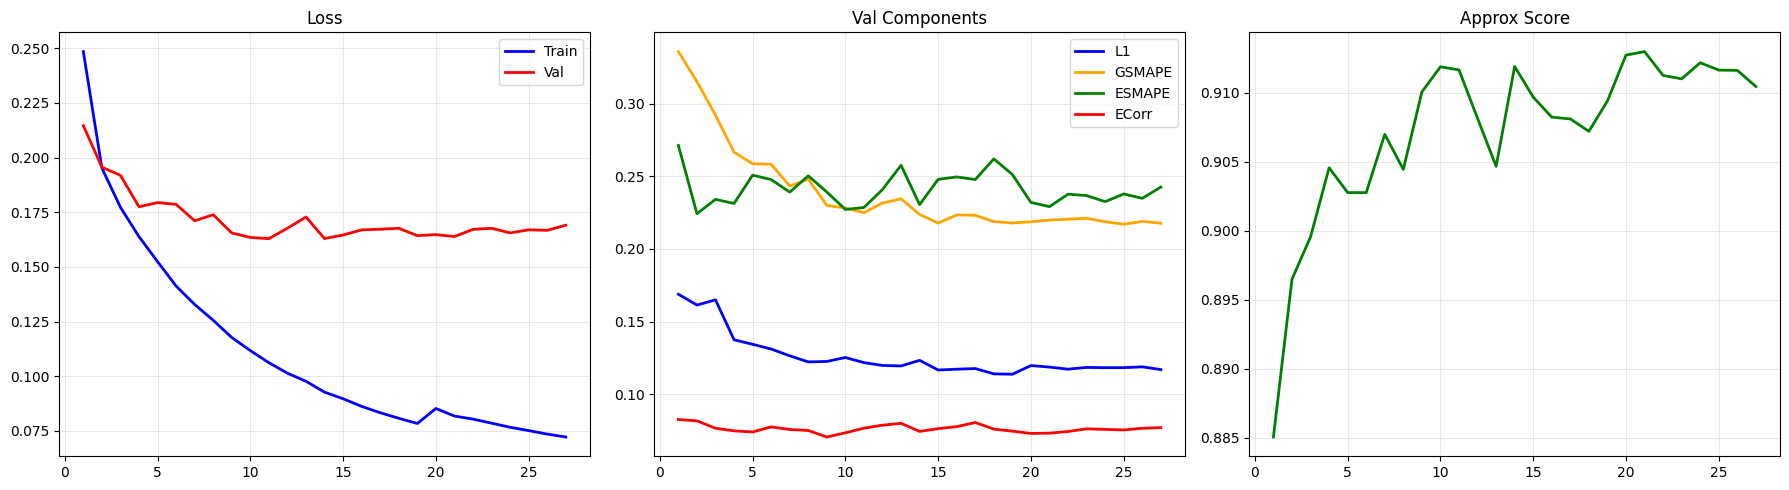

Peak score: 0.9130


In [11]:
# ═══ Training Curves ═══
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
eps = list(range(1, len(all_history)+1))
axes[0].plot(eps, [e['train_loss'] for e in all_history], 'b-', label='Train', linewidth=2)
axes[0].plot(eps, [e['val_loss'] for e in all_history], 'r-', label='Val', linewidth=2)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
for k,c,lb in [('l1','blue','L1'),('gs','orange','GSMAPE'),('es','green','ESMAPE'),('ec','red','ECorr')]:
    axes[1].plot(eps, [e[k] for e in all_history], label=lb, color=c, linewidth=2)
axes[1].set_title('Val Components'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[2].plot(eps, [e['score'] for e in all_history], 'g-', linewidth=2)
axes[2].set_title('Approx Score'); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'curves.png'), dpi=150)
plt.show()
print(f'Peak score: {max(e["score"] for e in all_history):.4f}')